# 03 Exploratory Data Analysis (EDA)


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

In [5]:
from pathlib import Path
from pandas.errors import EmptyDataError

clean_path = Path('../01_Dataset/Clean_Data/NovaMart_Retail_Cleaned.csv')

if not clean_path.exists() or clean_path.stat().st_size == 0:
    raise FileNotFoundError(
        'Cleaned dataset is missing or empty. Run 02_Data_Cleaning.ipynb fully, then retry EDA.'
    )

try:
    df = pd.read_csv(clean_path)
except EmptyDataError as exc:
    raise ValueError(
        'Cleaned dataset has no readable columns. Re-create it from 02_Data_Cleaning.ipynb.'
    ) from exc

if 'Order Date' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

df.head()

,Row ID,Order ID,Order Date,Year,Months,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016,November,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016,November,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016,June,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015,October,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,383.0310
4,5,US-2015-108966,2015-10-11,2015,October,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


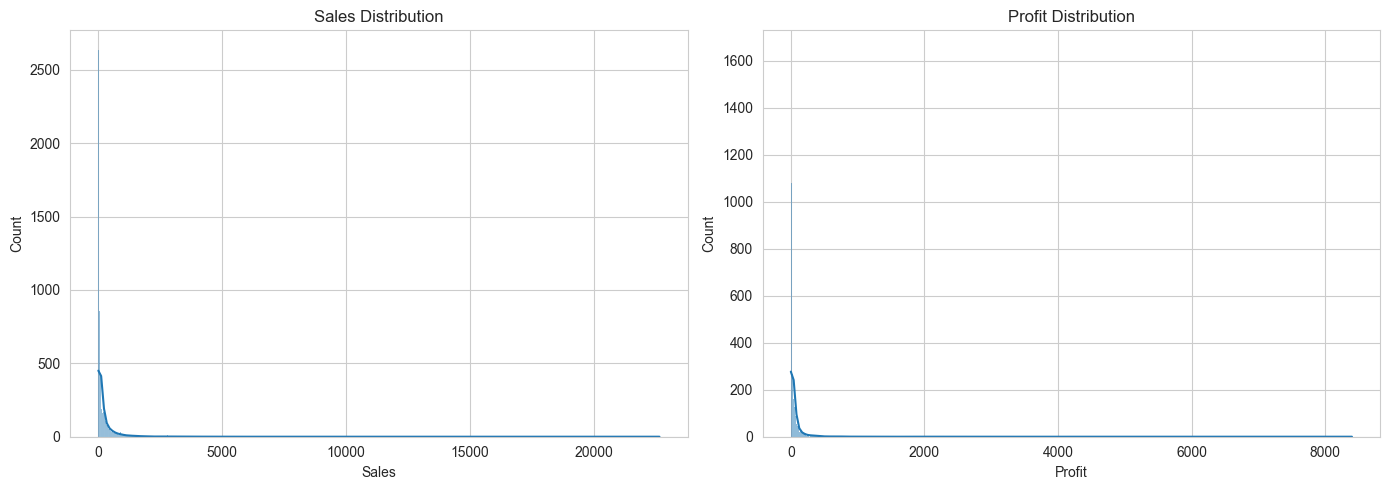

In [6]:
# Sales and Profit distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Sales'], kde=True, ax=axes[0])
axes[0].set_title('Sales Distribution')
sns.histplot(df['Profit'], kde=True, ax=axes[1])
axes[1].set_title('Profit Distribution')
plt.tight_layout()

In [7]:
# Orders by Region, Category, Segment
for dim in ['Region', 'Category', 'Segment']:
    if dim in df.columns and 'Order ID' in df.columns:
        print('\nOrders by', dim)
        print(df.groupby(dim)['Order ID'].nunique().sort_values(ascending=False))


Orders by Region
Region
West       1611
East       1401
Central    1175
South       822
Name: Order ID, dtype: int64

Orders by Category
Category
Office Supplies    3742
Furniture          1764
Technology         1544
Name: Order ID, dtype: int64

Orders by Segment
Segment
Consumer       2586
Corporate      1514
Home Office     909
Name: Order ID, dtype: int64


C:\Users\harsh\AppData\Local\Temp\ipykernel_148264\2174820081.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('Order Date').resample('M')['Sales'].sum()


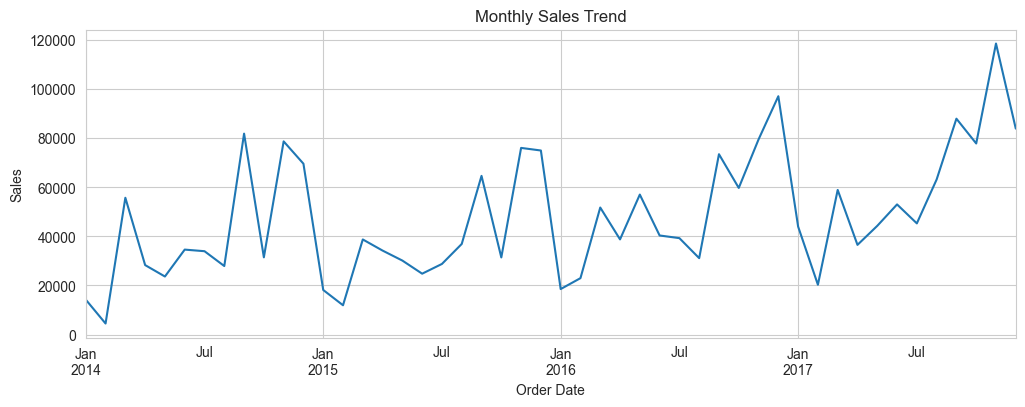

In [8]:
# Monthly sales trend
if 'Order Date' in df.columns:
    monthly = df.set_index('Order Date').resample('M')['Sales'].sum()
    monthly.plot(figsize=(12, 4), title='Monthly Sales Trend')
    plt.ylabel('Sales')
    plt.show()

In [9]:
# Top and Bottom 10 products by Sales
if 'Product Name' in df.columns and 'Sales' in df.columns:
    product_sales = df.groupby('Product Name', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
    print('Top 10 products by sales')
    print(product_sales.head(10))
    print('\nBottom 10 products by sales')
    print(product_sales.tail(10))

Top 10 products by sales
                                          Product Name      Sales
404              Canon imageCLASS 2200 Advanced Copier  61599.824
650  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
444  Cisco TelePresence System EX90 Videoconferenci...  22638.480
786       HON 5400 Series Task Chairs for Big and Tall  21870.576
686         GBC DocuBind TL300 Electric Binding System  19823.479
688   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
805               Hewlett Packard LaserJet 3310 Copier  18839.686
787  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
683          GBC DocuBind P400 Electric Binding System  17965.068
813        High Speed Automatic Electric Letter Opener  17030.312

Bottom 10 products by sales
                                           Product Name  Sales
1113                                         Newell 308  8.400
1509                         Stockwell Gold Paper Clips  8.096
27                             

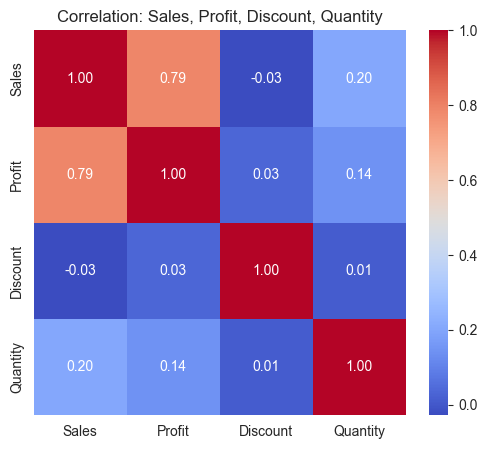

: 

In [ ]:
# Correlation matrix
corr_cols = [c for c in ['Sales', 'Profit', 'Discount', 'Quantity'] if c in df.columns]
corr = df[corr_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Sales, Profit, Discount, Quantity')
plt.show()